In [1]:
import sys
!{sys.executable} -m pip install tensorflow pandas numpy scikit-learn imbalanced-learn matplotlib seaborn openpyxl


In [3]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Reproducibility
seed = 42
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')


In [22]:
FILENAME = "UNSW_NB15_training-set.csv"  # do not change name per instruction
READ_FORMAT = "csv"  # "excel" for .xlsx or "csv" for .csv

def load_any(path, fmt):
    if fmt == "excel":
        return pd.read_excel(path)
    return pd.read_csv(path)

df = load_any(FILENAME, READ_FORMAT)
print("Shape:", df.shape)
df.head()


Shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,0,600000000.0,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0


In [23]:
print(df.info())
print(df.isnull().sum().sort_values(ascending=False).head(10))

# Drop exact duplicates and any all-NA rows
df = df.drop_duplicates().dropna(how='all').reset_index(drop=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [24]:
mode = "multiclass"  # change to "binary" if only Normal vs Attack is needed


In [25]:
# Categorical feature columns present in UNSW-NB15
categorical_cols = ['proto', 'service', 'state']

# Encode feature categories
for c in categorical_cols:
    le_feat = LabelEncoder()
    df[c] = le_feat.fit_transform(df[c].astype(str))

if mode == "binary":
    target_col = 'label'
    assert set(df[target_col].unique()) <= {0,1}, "label must be 0/1 for binary mode"
else:
    target_col = 'attack_cat'
    y_le = LabelEncoder()
    df['attack_cat_enc'] = y_le.fit_transform(df['attack_cat'].astype(str))
    print("Classes:", list(y_le.classes_))


Classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [26]:
# Drop non-predictive or identifiers
drop_cols = ['id']
to_drop = set(drop_cols + [target_col])
if mode == "multiclass":
    # y will be attack_cat_enc; keep attack_cat only for reporting
    pass

X = df.drop(columns=list(to_drop), errors='ignore')
y = df['label'] if mode == "binary" else df['attack_cat_enc']

# Train/validation split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train/Test:", X_train.shape, X_test.shape)


Train/Test: (65865, 44) (16467, 44)


In [27]:
# Scale numeric features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Handle class imbalance (recommended)
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_sc, y_train)
print("After SMOTE:", X_train_bal.shape)


After SMOTE: (296000, 44)


In [28]:
# CNN+LSTM expects (samples, timesteps, channels); treat each feature vector as a 1D sequence
timesteps = X_train_bal.shape[1]
X_train_3d = X_train_bal.reshape((X_train_bal.shape[0], timesteps, 1))
X_test_3d  = X_test_sc.reshape((X_test_sc.shape[0], timesteps, 1))

if mode == "multiclass":
    num_classes = len(np.unique(y_train_bal))
    y_train_out = tf.keras.utils.to_categorical(y_train_bal, num_classes)
    y_test_out  = tf.keras.utils.to_categorical(y_test, num_classes)
else:
    num_classes = 2
    y_train_out = y_train_bal
    y_test_out  = y_test


In [29]:
def build_cnn_lstm_v1(input_steps, num_classes, binary=False):
    model = Sequential()
    model.add(Conv1D(64, 3, activation='relu', input_shape=(input_steps,1)))
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.30))

    model.add(Conv1D(128, 3, activation='relu'))
    model.add(MaxPooling1D(2))
    model.add(Dropout(0.30))

    model.add(LSTM(128))
    model.add(Dropout(0.30))

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.30))

    if binary:
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    else:
        model.add(Dense(num_classes, activation='softmax'))
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

binary_flag = (mode=="binary")
model = build_cnn_lstm_v1(timesteps, num_classes, binary=binary_flag)
model.summary()


C:\Users\acer\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 42, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 19, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 9, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,346 (681.04 KB)

 Trainable params: 174,346 (681.04 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
ckpt = 'best_cnn_lstm.keras'
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint(ckpt, monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    X_train_3d, y_train_out,
    validation_split=0.2,
    epochs=80,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 91s 24ms/step - accuracy: 0.6065 - loss: 1.0208 - val_accuracy: 0.0050 - val_loss: 6.2989 - learning_rate: 0.0010
Epoch 2/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 86s 23ms/step - accuracy: 0.6698 - loss: 0.8290 - val_accuracy: 0.0049 - val_loss: 5.6183 - learning_rate: 0.0010
Epoch 3/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 88s 24ms/step - accuracy: 0.6843 - loss: 0.7851 - val_accuracy: 0.0055 - val_loss: 5.8508 - learning_rate: 0.0010
Epoch 4/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 89s 24ms/step - accuracy: 0.6930 - loss: 0.7599 - val_accuracy: 0.0173 - val_loss: 5.3358 - learning_rate: 0.0010
Epoch 5/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 89s 24ms/step - accuracy: 0.6982 - loss: 0.7410 - val_accuracy: 0.0076 - val_loss: 5.1802 - learning_rate: 0.0010
Epoch 6/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 90s 24ms/step - accuracy: 0.7024 - loss: 0.7261 - val_accuracy: 0.0130 - val_loss: 5.1607 - learning_rate: 0.0010
Epoch 7/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 94s 25ms/step - accura

515/515 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step
Balanced Accuracy: 0.544258585035474
                precision    recall  f1-score   support

      Analysis       0.08      0.10      0.09       135
      Backdoor       0.12      0.73      0.21       117
           DoS       0.35      0.65      0.45       818
      Exploits       0.84      0.50      0.63      2227
       Fuzzers       0.73      0.66      0.69      1212
       Generic       1.00      0.96      0.98      3774
        Normal       0.97      0.93      0.95      7400
Reconnaissance       0.60      0.84      0.70       699
     Shellcode       1.00      0.08      0.15        76
         Worms       0.00      0.00      0.00         9

      accuracy                           0.83     16467
     macro avg       0.57      0.54      0.48     16467
  weighted avg       0.88      0.83      0.84     16467



C:\Users\acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


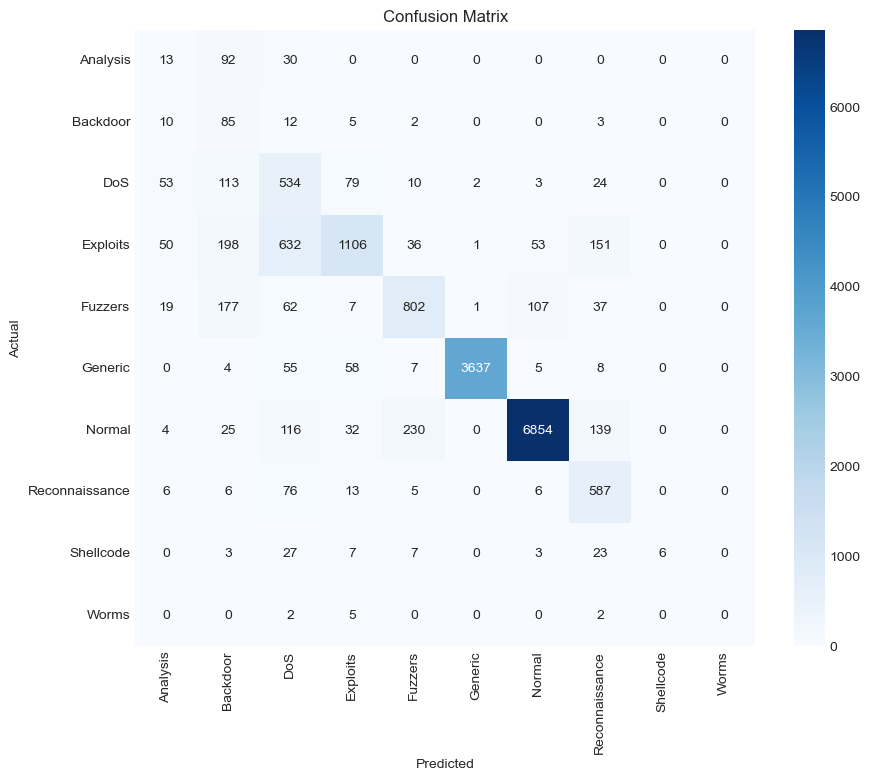

In [31]:
if mode == "binary":
    y_prob = model.predict(X_test_3d).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    print("Balanced Accuracy:", balanced_accuracy_score(y_test_out, y_pred))
    print(classification_report(y_test_out, y_pred, target_names=['Normal','Attack']))
else:
    y_prob = model.predict(X_test_3d)
    y_pred = np.argmax(y_prob, axis=1)
    print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
    # If you want readable class names:
    target_names = list(y_le.classes_)
    print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test if mode=="multiclass" else y_test_out, y_pred)
plt.figure(figsize=(10,8))
ticks = (target_names if mode=="multiclass" else ['Normal','Attack'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=ticks, yticklabels=ticks)
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()


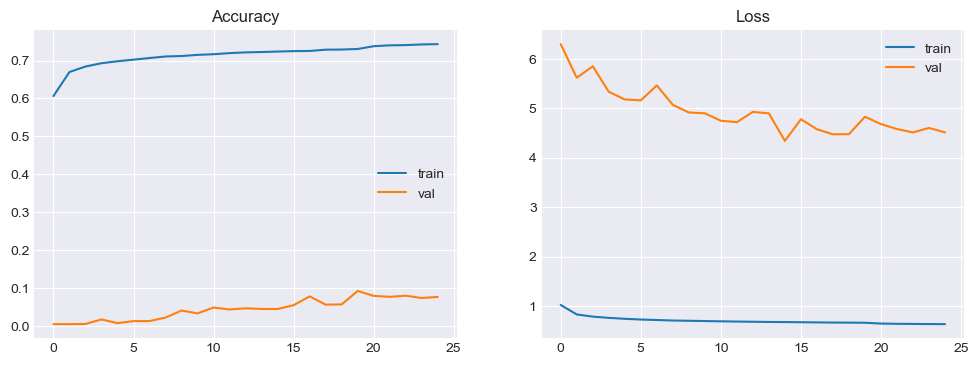

In [32]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(history.history['accuracy']); plt.plot(history.history['val_accuracy'])
plt.title('Accuracy'); plt.legend(['train','val'])
plt.subplot(1,2,2); plt.plot(history.history['loss']); plt.plot(history.history['val_loss'])
plt.title('Loss'); plt.legend(['train','val']); plt.show()


In [33]:
model.save('final_cnn_lstm.keras')

import pickle
with open('scaler.pkl','wb') as f: pickle.dump(scaler, f)
if mode == "multiclass":
    with open('attack_label_encoder.pkl','wb') as f: pickle.dump(y_le, f)


In [34]:
def build_cnn_lstm_v2(input_steps, num_classes, binary=False):
    m = Sequential()
    m.add(Conv1D(128, 5, activation='relu', input_shape=(input_steps,1)))
    m.add(MaxPooling1D(2)); m.add(Dropout(0.35))
    m.add(Conv1D(256, 3, activation='relu'))
    m.add(MaxPooling1D(2)); m.add(Dropout(0.35))
    m.add(Bidirectional(LSTM(128)))
    m.add(Dropout(0.40))
    m.add(Dense(256, activation='relu')); m.add(Dropout(0.40))
    if binary:
        m.add(Dense(1, activation='sigmoid'))
        m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    else:
        m.add(Dense(num_classes, activation='softmax'))
        m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m


In [35]:
opt = tf.keras.optimizers.Adam(learning_rate=1e-3)  # try 1e-3 then 5e-4
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]


In [37]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {c:w for c,w in zip(classes, cw)}

history = model.fit(X_train_3d, y_train_out, validation_split=0.2,
                    epochs=80, batch_size=64, callbacks=callbacks,
                    class_weight=class_weights, verbose=1)


Epoch 1/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 88s 23ms/step - accuracy: 0.6757 - loss: 3.1319 - val_accuracy: 0.2921 - val_loss: 2.0974 - learning_rate: 0.0010
Epoch 2/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 84s 23ms/step - accuracy: 0.6670 - loss: 3.1116 - val_accuracy: 0.2861 - val_loss: 3.7555 - learning_rate: 0.0010
Epoch 3/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 86s 23ms/step - accuracy: 0.6667 - loss: 3.0965 - val_accuracy: 0.3607 - val_loss: 1.8369 - learning_rate: 0.0010
Epoch 4/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 84s 23ms/step - accuracy: 0.6597 - loss: 3.1333 - val_accuracy: 0.3344 - val_loss: 2.2897 - learning_rate: 0.0010
Epoch 5/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 85s 23ms/step - accuracy: 0.6588 - loss: 3.1291 - val_accuracy: 0.5271 - val_loss: 1.6083 - learning_rate: 0.0010
Epoch 6/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 88s 24ms/step - accuracy: 0.6542 - loss: 3.1682 - val_accuracy: 0.4480 - val_loss: 1.7721 - learning_rate: 0.0010
Epoch 7/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 87s 24ms/step - accura

In [38]:
def build_cnn_lstm_strong(steps, num_classes):
    m = tf.keras.Sequential([
        Conv1D(128, 5, activation='relu', input_shape=(steps,1)),
        MaxPooling1D(2), Dropout(0.35),
        Conv1D(256, 3, activation='relu'),
        MaxPooling1D(2), Dropout(0.35),
        Bidirectional(LSTM(128)), Dropout(0.4),
        Dense(256, activation='relu'), Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m


In [39]:
from sklearn.metrics import balanced_accuracy_score, classification_report
y_val_prob = model.predict(X_test_3d)
y_val_pred = np.argmax(y_val_prob, axis=1)
print("Balanced Acc:", balanced_accuracy_score(y_test, y_val_pred))
print(classification_report(y_test, y_val_pred, target_names=list(y_le.classes_)))


515/515 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step
Balanced Acc: 0.6066760082868934
                precision    recall  f1-score   support

      Analysis       0.06      0.26      0.09       135
      Backdoor       0.07      0.48      0.12       117
           DoS       0.26      0.41      0.32       818
      Exploits       0.91      0.35      0.51      2227
       Fuzzers       0.33      0.73      0.45      1212
       Generic       1.00      0.96      0.98      3774
        Normal       1.00      0.69      0.82      7400
Reconnaissance       0.55      0.85      0.67       699
     Shellcode       0.28      0.45      0.34        76
         Worms       0.04      0.89      0.07         9

      accuracy                           0.70     16467
     macro avg       0.45      0.61      0.44     16467
  weighted avg       0.86      0.70      0.74     16467



In [41]:
opt = tf.keras.optimizers.Adam(learning_rate=5e-4)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    X_train_3d, y_train_out,
    validation_split=0.2,
    epochs=80, batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ],
    class_weight=class_weights,
    verbose=1
)


Epoch 1/80
7400/7400 ━━━━━━━━━━━━━━━━━━━━ 168s 22ms/step - accuracy: 0.6712 - loss: 3.0236 - val_accuracy: 0.5651 - val_loss: 1.7903 - learning_rate: 5.0000e-04
Epoch 2/80
7400/7400 ━━━━━━━━━━━━━━━━━━━━ 165s 22ms/step - accuracy: 0.6705 - loss: 2.9852 - val_accuracy: 0.4973 - val_loss: 2.0356 - learning_rate: 5.0000e-04
Epoch 3/80
7400/7400 ━━━━━━━━━━━━━━━━━━━━ 148s 20ms/step - accuracy: 0.6695 - loss: 3.0334 - val_accuracy: 0.6190 - val_loss: 1.5317 - learning_rate: 5.0000e-04
Epoch 4/80
7400/7400 ━━━━━━━━━━━━━━━━━━━━ 149s 20ms/step - accuracy: 0.6691 - loss: 3.0443 - val_accuracy: 0.6458 - val_loss: 1.4055 - learning_rate: 5.0000e-04
Epoch 5/80
7400/7400 ━━━━━━━━━━━━━━━━━━━━ 148s 20ms/step - accuracy: 0.6689 - loss: 2.9910 - val_accuracy: 0.6037 - val_loss: 1.5779 - learning_rate: 5.0000e-04
Epoch 6/80
7400/7400 ━━━━━━━━━━━━━━━━━━━━ 152s 21ms/step - accuracy: 0.6708 - loss: 2.9904 - val_accuracy: 0.5795 - val_loss: 1.8786 - learning_rate: 5.0000e-04
Epoch 7/80
7398/7400 ━━━━━━━━━━━━━

In [43]:
# Rebuild strong model
def build_cnn_lstm_strong(steps, num_classes):
    m = tf.keras.Sequential([
        tf.keras.layers.Conv1D(128, 5, activation='relu', input_shape=(steps,1)),
        tf.keras.layers.MaxPooling1D(2), tf.keras.layers.Dropout(0.35),
        tf.keras.layers.Conv1D(256, 3, activation='relu'),
        tf.keras.layers.MaxPooling1D(2), tf.keras.layers.Dropout(0.35),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128)),
        tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(256, activation='relu'), tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # use sigmoid/1 unit for binary
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

model = build_cnn_lstm_strong(timesteps, num_classes)

# Class weights instead of SMOTE for stability
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = {int(c):float(w) for c,w in zip(classes, cw)}

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    X_train_3d, y_train_out,          # y_train_cat for multiclass, y_train for binary
    validation_split=0.2,
    epochs=80,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/80


C:\Users\acer\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3700/3700 ━━━━━━━━━━━━━━━━━━━━ 106s 28ms/step - accuracy: 0.7544 - loss: 1.0534 - val_accuracy: 0.2607 - val_loss: 1.1028 - learning_rate: 5.0000e-04
Epoch 2/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 101s 27ms/step - accuracy: 0.9458 - loss: 0.1635 - val_accuracy: 1.0000 - val_loss: 0.1416 - learning_rate: 5.0000e-04
Epoch 3/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 104s 28ms/step - accuracy: 0.9841 - loss: 0.0711 - val_accuracy: 0.8478 - val_loss: 0.2692 - learning_rate: 5.0000e-04
Epoch 4/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 103s 28ms/step - accuracy: 0.9895 - loss: 0.0711 - val_accuracy: 0.9999 - val_loss: 0.0167 - learning_rate: 5.0000e-04
Epoch 5/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 102s 28ms/step - accuracy: 0.9920 - loss: 0.0531 - val_accuracy: 1.0000 - val_loss: 0.0315 - learning_rate: 5.0000e-04
Epoch 6/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 104s 28ms/step - accuracy: 0.9939 - loss: 0.0403 - val_accuracy: 0.9133 - val_loss: 0.1509 - learning_rate: 5.0000e-04
Epoch 7/80
3700/3700 ━━━━━━━━━━━━━━━━━━━━ 102

In [44]:
print("Train 3D:", X_train_3d.shape, "Test 3D:", X_test_3d.shape)
print("y_train uniq:", np.unique(y_train))
print("y_test  uniq:", np.unique(y_test))


Train 3D: (296000, 44, 1) Test 3D: (16467, 44, 1)
y_train uniq: [0 1 2 3 4 5 6 7 8 9]
y_test  uniq: [0 1 2 3 4 5 6 7 8 9]


In [45]:
# Make a fresh stratified split from the original, non-resampled data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

# X_raw, y_raw should be built from the original df before SMOTE
X_raw = df.drop(columns=['id','attack_cat','label'], errors='ignore')  # adjust if needed
y_raw = df['attack_cat_enc']  # or df['label'] for binary

X_tr, X_va, y_tr, y_va = train_test_split(X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42)

# Fit encoders/scaler on training only (categoricals already encoded above)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_va_sc = scaler.transform(X_va)

# Shape for CNN+LSTM
X_tr_3d = X_tr_sc.reshape((X_tr_sc.shape[0], X_tr_sc.shape[1], 1))
X_va_3d = X_va_sc.reshape((X_va_sc.shape[0], X_va_sc.shape[1], 1))

# If multiclass with integer labels, either use one-hot + categorical_crossentropy or sparse loss
num_classes = len(np.unique(y_tr))
y_tr_onehot = tf.keras.utils.to_categorical(y_tr, num_classes)
y_va_onehot = tf.keras.utils.to_categorical(y_va, num_classes)

# Re-train briefly or just evaluate current model if trained similarly on X_tr_3d
val_probs = model.predict(X_va_3d)
val_pred = np.argmax(val_probs, axis=1)
print("Validation Balanced Acc:", balanced_accuracy_score(y_va, val_pred))
print(classification_report(y_va, val_pred))
print(confusion_matrix(y_va, val_pred))


515/515 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step
Validation Balanced Acc: 0.2221677045528839
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       135
           1       0.00      0.00      0.00       117
           2       0.00      0.00      0.00       818
           3       0.83      0.02      0.03      2227
           4       0.16      0.98      0.27      1212
           5       0.51      0.94      0.66      3774
           6       1.00      0.18      0.30      7400
           7       0.22      0.11      0.14       699
           8       0.00      0.00      0.00        76
           9       0.00      0.00      0.00         9

    accuracy                           0.38     16467
   macro avg       0.27      0.22      0.14     16467
weighted avg       0.70      0.38      0.32     16467

[[   0    0    0    0  128    7    0    0    0    0]
 [   0    0    0    0  109    7    0    1    0    0]
 [   0    0    0    0  686   91    0   25   15    

C:\Users\acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [48]:
# 1) Class weights from training labels (integer y_train)
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = {int(c): float(w) for c, w in zip(classes, cw)}

# 2) Focal loss for multi-class (gamma tunes focus on hard examples)
import tensorflow as tf
def categorical_focal_loss(gamma=2.0, alpha=None, epsilon=1e-7):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        ce = -y_true * tf.math.log(y_pred)
        if alpha is not None:
            ce = alpha * ce
        weight = tf.pow(1 - y_pred, gamma)
        fl = weight * ce
        return tf.reduce_sum(fl, axis=-1)
    return loss

num_classes = len(np.unique(y_train))
alpha_vec = tf.constant([class_weights.get(i, 1.0) for i in range(num_classes)], dtype=tf.float32)

# 3) Recompile model with focal loss and lower LR
opt = tf.keras.optimizers.Adam(learning_rate=5e-4)
model.compile(optimizer=opt, loss=categorical_focal_loss(gamma=2.0, alpha=alpha_vec), metrics=['accuracy'])

# 4) Macro-F1 metric callback (evaluation at epoch end)
from sklearn.metrics import f1_score
class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val_int):
        super().__init__()
        self.Xv, self.yv = X_val, y_val_int
    def on_epoch_end(self, epoch, logs=None):
        yp = self.model.predict(self.Xv, verbose=0)
        yp_cls = yp.argmax(axis=1)
        mf1 = f1_score(self.yv, yp_cls, average='macro', zero_division=0)
        logs = logs or {}
        logs['val_macro_f1'] = mf1
        print(f" — val_macro_f1: {mf1:.4f}")

macro_cb = MacroF1Callback(X_test_3d, y_test)  # if using test as validation here, prefer a held-out val split

# 5) Train with stronger LR scheduling and early stop
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    macro_cb
]

history = model.fit(
    X_train_3d, y_train_out,
    validation_data=(X_test_3d, y_test_out),
    epochs=80,
    batch_size=64,
    class_weight=class_weights,  # still helpful with focal
    callbacks=callbacks,
    verbose=1
)


Epoch 1/80
 — val_macro_f1: 0.9690━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9700 - loss: 26.1289   
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 170s 36ms/step - accuracy: 0.9589 - loss: 10.3665 - val_accuracy: 0.9829 - val_loss: 0.0108 - learning_rate: 5.0000e-04 - val_macro_f1: 0.9690
Epoch 2/80
 — val_macro_f1: 0.8605━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9316 - loss: 5.7471   
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 120s 26ms/step - accuracy: 0.9300 - loss: 5.1120 - val_accuracy: 0.8766 - val_loss: 0.0764 - learning_rate: 5.0000e-04 - val_macro_f1: 0.8605
Epoch 3/80
 — val_macro_f1: 0.8067━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8719 - loss: 4.0974  
4625/4625 ━━━━━━━━━━━━━━━━━━━━ 125s 27ms/step - accuracy: 0.8525 - loss: 4.7817 - val_accuracy: 0.8182 - val_loss: 0.0956 - learning_rate: 5.0000e-04 - val_macro_f1: 0.8067
Epoch 4/80
4622/4625 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8589 - loss: 2.0905  
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628

In [49]:
# Make a fresh stratified split from the original, non-resampled data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

# X_raw, y_raw should be built from the original df before SMOTE
X_raw = df.drop(columns=['id','attack_cat','label'], errors='ignore')  # adjust if needed
y_raw = df['attack_cat_enc']  # or df['label'] for binary

X_tr, X_va, y_tr, y_va = train_test_split(X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42)

# Fit encoders/scaler on training only (categoricals already encoded above)
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_va_sc = scaler.transform(X_va)

# Shape for CNN+LSTM
X_tr_3d = X_tr_sc.reshape((X_tr_sc.shape[0], X_tr_sc.shape[1], 1))
X_va_3d = X_va_sc.reshape((X_va_sc.shape[0], X_va_sc.shape[1], 1))

# If multiclass with integer labels, either use one-hot + categorical_crossentropy or sparse loss
num_classes = len(np.unique(y_tr))
y_tr_onehot = tf.keras.utils.to_categorical(y_tr, num_classes)
y_va_onehot = tf.keras.utils.to_categorical(y_va, num_classes)

# Re-train briefly or just evaluate current model if trained similarly on X_tr_3d
val_probs = model.predict(X_va_3d)
val_pred = np.argmax(val_probs, axis=1)
print("Validation Balanced Acc:", balanced_accuracy_score(y_va, val_pred))
print(classification_report(y_va, val_pred))
print(confusion_matrix(y_va, val_pred))


515/515 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step
Validation Balanced Acc: 0.2135358358629141
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       135
           1       0.00      0.00      0.00       117
           2       0.00      0.00      0.00       818
           3       0.19      0.00      0.01      2227
           4       0.15      0.97      0.26      1212
           5       0.55      0.95      0.69      3774
           6       1.00      0.10      0.19      7400
           7       0.08      0.11      0.09       699
           8       0.00      0.00      0.00        76
           9       0.00      0.00      0.00         9

    accuracy                           0.34     16467
   macro avg       0.20      0.21      0.12     16467
weighted avg       0.61      0.34      0.27     16467

[[   0    0    0    0  125   10    0    0    0    0]
 [   0    0    0    0  109    6    0    2    0    0]
 [   0    0    0    1  709   24    0   68   15   

C:\Users\acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
# 1) Class weights from your new training split (y_tr are integer labels)
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_tr)
cw = compute_class_weight('balanced', classes=classes, y=y_tr)
class_weights = {int(c): float(w) for c, w in zip(classes, cw)}

# 2) Build a stronger, regularized CNN+BiLSTM
def build_cnn_bilstm(input_steps, num_classes):
    m = tf.keras.Sequential([
        tf.keras.layers.Conv1D(128, 5, activation='relu', input_shape=(input_steps,1)),
        tf.keras.layers.MaxPooling1D(2), tf.keras.layers.Dropout(0.35),
        tf.keras.layers.Conv1D(256, 3, activation='relu'),
        tf.keras.layers.MaxPooling1D(2), tf.keras.layers.Dropout(0.35),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128)),
        tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return m

steps = X_tr_3d.shape[1]
num_classes = len(np.unique(y_tr))
model = build_cnn_bilstm(steps, num_classes)

# 3) Use focal loss + lower LR
def categorical_focal_loss(gamma=2.0, alpha=None, epsilon=1e-7):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        ce = -y_true * tf.math.log(y_pred)
        if alpha is not None:
            ce = alpha * ce
        weight = tf.pow(1 - y_pred, gamma)
        fl = weight * ce
        return tf.reduce_sum(fl, axis=-1)
    return loss

alpha_vec = tf.constant([class_weights.get(i, 1.0) for i in range(num_classes)], dtype=tf.float32)
opt = tf.keras.optimizers.Adam(learning_rate=5e-4)
model.compile(optimizer=opt, loss=categorical_focal_loss(gamma=2.0, alpha=alpha_vec), metrics=['accuracy'])

# 4) Prepare one-hot labels for this compile; alternatively switch to sparse focal loss
y_tr_oh = tf.keras.utils.to_categorical(y_tr, num_classes)
y_va_oh = tf.keras.utils.to_categorical(y_va, num_classes)

# 5) Callbacks and training
cbs = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

hist = model.fit(
    X_tr_3d, y_tr_oh,
    validation_data=(X_va_3d, y_va_oh),
    epochs=80, batch_size=64,
    class_weight=class_weights,  # still beneficial with focal
    callbacks=cbs, verbose=1
)


C:\Users\acer\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 49s 44ms/step - accuracy: 0.0018 - loss: 21.0059 - val_accuracy: 6.0728e-04 - val_loss: 2.9979 - learning_rate: 5.0000e-04
Epoch 2/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.0046 - loss: 11.7702 - val_accuracy: 0.0074 - val_loss: 2.9463 - learning_rate: 5.0000e-04
Epoch 3/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.0062 - loss: 15.0698 - val_accuracy: 0.0032 - val_loss: 3.4678 - learning_rate: 5.0000e-04
Epoch 4/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.0062 - loss: 11.5547 - val_accuracy: 0.0072 - val_loss: 2.6560 - learning_rate: 5.0000e-04
Epoch 5/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.0075 - loss: 12.4406 - val_accuracy: 0.0079 - val_loss: 2.7490 - learning_rate: 5.0000e-04
Epoch 6/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.0081 - loss: 17.2619 - val_accuracy: 0.0052 - val_loss: 3.1111 - learning_rate: 5.0000e-04
Epoch 7/80
1030/1030 ━━━━━━━━━

In [51]:
num_classes = len(np.unique(y_tr))
model.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

hist = model.fit(
    X_tr_3d, y_tr,                 # integers, not one-hot
    validation_data=(X_va_3d, y_va),
    epochs=80, batch_size=64,
    callbacks=cbs, verbose=1
)


Epoch 1/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 40s 36ms/step - accuracy: 0.7216 - loss: 0.8031 - val_accuracy: 0.7860 - val_loss: 0.5739 - learning_rate: 5.0000e-04
Epoch 2/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.7973 - loss: 0.5715 - val_accuracy: 0.8262 - val_loss: 0.4859 - learning_rate: 5.0000e-04
Epoch 3/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 38s 37ms/step - accuracy: 0.8174 - loss: 0.5110 - val_accuracy: 0.8347 - val_loss: 0.4552 - learning_rate: 5.0000e-04
Epoch 4/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 35s 34ms/step - accuracy: 0.8271 - loss: 0.4834 - val_accuracy: 0.8391 - val_loss: 0.4381 - learning_rate: 5.0000e-04
Epoch 5/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 37s 36ms/step - accuracy: 0.8321 - loss: 0.4644 - val_accuracy: 0.8413 - val_loss: 0.4313 - learning_rate: 5.0000e-04
Epoch 6/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 36s 35ms/step - accuracy: 0.8356 - loss: 0.4530 - val_accuracy: 0.8424 - val_loss: 0.4214 - learning_rate: 5.0000e-04
Epoch 7/80
1030/1030 ━━━━━━━━━━━━━━━━━━━

In [53]:
print(X_tr_3d.shape, X_va_3d.shape)


(65865, 43, 1) (16467, 43, 1)


In [54]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_tr)
cw = compute_class_weight('balanced', classes=classes, y=y_tr)
class_weights = {int(c): float(w) for c,w in zip(classes, cw)}

cbs = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

hist = model.fit(
    X_tr_3d, y_tr,
    validation_data=(X_va_3d, y_va),
    epochs=80, batch_size=64,
    class_weight=class_weights,
    callbacks=cbs, verbose=1
)


Epoch 1/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.8646 - loss: 1.3452 - val_accuracy: 0.8640 - val_loss: 0.3509 - learning_rate: 3.9063e-06
Epoch 2/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.8633 - loss: 1.2560 - val_accuracy: 0.8637 - val_loss: 0.3532 - learning_rate: 3.9063e-06
Epoch 3/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.8620 - loss: 1.2406 - val_accuracy: 0.8630 - val_loss: 0.3559 - learning_rate: 3.9063e-06
Epoch 4/80
1029/1030 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8610 - loss: 1.2935 
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.8609 - loss: 1.1986 - val_accuracy: 0.8618 - val_loss: 0.3588 - learning_rate: 3.9063e-06
Epoch 5/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.8593 - loss: 1.1935 - val_accuracy: 0.8579 - val_loss: 0.3602 - learning_rate: 1.9531e-06
Epoch 6/80
1030/1030 ━━━━━━━━━━━━━━━━━━━━ 42

In [55]:
TEST_FILE = "UNSW_NB15_testing-set.csv"
test_df = pd.read_csv(TEST_FILE)

# Ensure consistent capitalization/whitespace for mapping
test_df['attack_cat'] = test_df['attack_cat'].astype(str).str.strip().str.title()


In [56]:
attack_to_4 = {
    'Worms': 'Ransomware',
    'Backdoor': 'Ransomware',
    'Fuzzers': 'Malware',
    'Shellcode': 'Malware',
    'Generic': 'Malware',
    'Dos': 'Ddos',
    'Reconnaissance': 'Phishing',
    'Exploits': 'Phishing',
    'Analysis': 'Phishing',
    'Normal': 'Normal'
}
test_df['attack_4'] = test_df['attack_cat'].map(attack_to_4).fillna('Other')

In [57]:
import numpy as np

# Columns you categorical-encoded during training
cat_cols = list(encoders_feat.keys())

# 1) Define an UNK token and extend encoder classes if needed
UNK = "__UNK__"

def extend_label_encoder(le, new_values):
    # new_values: array-like of strings seen in test
    known = set(le.classes_.tolist())
    new = sorted(set(new_values) - known)
    if new:
        le.classes_ = np.array(le.classes_.tolist() + [UNK])
    return le

# 2) Prepare test copy and fill unseen with UNK, then transform
X_test_ext = test_df[X.columns].copy()

for c in cat_cols:
    # Cast to string and strip
    test_vals = X_test_ext[c].astype(str).str.strip()
    # Identify unseen values
    seen = set(encoders_feat[c].classes_.tolist())
    unseen_mask = ~test_vals.isin(seen)
    if unseen_mask.any():
        # Extend encoder by adding UNK once if not present
        if UNK not in encoders_feat[c].classes_:
            encoders_feat[c].classes_ = np.array(list(encoders_feat[c].classes_) + [UNK])
        # Replace unseen with UNK
        test_vals.loc[unseen_mask] = UNK
    # Assign back and transform
    X_test_ext[c] = encoders_feat[c].transform(test_vals)

# Now scale and reshape
X_test_sc_ext = scaler.transform(X_test_ext)
X_test_3d_ext = X_test_sc_ext.reshape((X_test_sc_ext.shape[0], X_test_sc_ext.shape[1], 1))


NameError: name 'encoders_feat' is not defined

In [58]:
import pickle

with open('feature_encoders.pkl','rb') as f:
    encoders_feat = pickle.load(f)

with open('x_columns.pkl','rb') as f:
    X_columns = pickle.load(f)

# Ensure X uses the same feature order
X = X[X_columns] if 'X' in globals() else test_df[X_columns].copy()
cat_cols = list(encoders_feat.keys())


In [59]:
import numpy as np

# Columns you categorical-encoded during training
cat_cols = list(encoders_feat.keys())

# 1) Define an UNK token and extend encoder classes if needed
UNK = "__UNK__"

def extend_label_encoder(le, new_values):
    # new_values: array-like of strings seen in test
    known = set(le.classes_.tolist())
    new = sorted(set(new_values) - known)
    if new:
        le.classes_ = np.array(le.classes_.tolist() + [UNK])
    return le

# 2) Prepare test copy and fill unseen with UNK, then transform
X_test_ext = test_df[X.columns].copy()

for c in cat_cols:
    # Cast to string and strip
    test_vals = X_test_ext[c].astype(str).str.strip()
    # Identify unseen values
    seen = set(encoders_feat[c].classes_.tolist())
    unseen_mask = ~test_vals.isin(seen)
    if unseen_mask.any():
        # Extend encoder by adding UNK once if not present
        if UNK not in encoders_feat[c].classes_:
            encoders_feat[c].classes_ = np.array(list(encoders_feat[c].classes_) + [UNK])
        # Replace unseen with UNK
        test_vals.loc[unseen_mask] = UNK
    # Assign back and transform
    X_test_ext[c] = encoders_feat[c].transform(test_vals)

# Now scale and reshape
X_test_sc_ext = scaler.transform(X_test_ext)
X_test_3d_ext = X_test_sc_ext.reshape((X_test_sc_ext.shape[0], X_test_sc_ext.shape[1], 1))


ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- attack_cat_enc


In [60]:
import pickle

# Reload artifacts
with open('x_columns.pkl','rb') as f:
    X_columns = pickle.load(f)          # exact feature list used to fit the scaler
with open('feature_encoders.pkl','rb') as f:
    encoders_feat = pickle.load(f)      # dict of LabelEncoders
with open('scaler.pkl','rb') as f:
    scaler = pickle.load(f)             # StandardScaler fit on training features

# Build X_test_ext using the same columns and order
X_test_ext = test_df[X_columns].copy()

# Encode categorical features consistently
UNK = "__UNK__"
for c, enc in encoders_feat.items():
    vals = X_test_ext[c].astype(str).str.strip()
    seen = set(enc.classes_.tolist())
    unseen = ~vals.isin(seen)
    if unseen.any():
        if UNK not in enc.classes_:
            enc.classes_ = np.array(list(enc.classes_) + [UNK])
        vals.loc[unseen] = UNK
    X_test_ext[c] = enc.transform(vals)

# Now scale and reshape
X_test_sc_ext = scaler.transform(X_test_ext)  # succeeds because columns match
X_test_3d_ext = X_test_sc_ext.reshape((X_test_sc_ext.shape[0], X_test_sc_ext.shape[1], 1))


In [61]:
print("Scaler fitted on:", getattr(scaler, 'feature_names_in_', X_columns))
print("Test columns now: ", list(X_test_ext.columns))
assert list(getattr(scaler, 'feature_names_in_', X_columns)) == list(X_test_ext.columns)


Scaler fitted on: ['dur' 'proto' 'service' 'state' 'spkts' 'dpkts' 'sbytes' 'dbytes' 'rate'
 'sttl' 'dttl' 'sload' 'dload' 'sloss' 'dloss' 'sinpkt' 'dinpkt' 'sjit'
 'djit' 'swin' 'stcpb' 'dtcpb' 'dwin' 'tcprtt' 'synack' 'ackdat' 'smean'
 'dmean' 'trans_depth' 'response_body_len' 'ct_srv_src' 'ct_state_ttl'
 'ct_dst_ltm' 'ct_src_dport_ltm' 'ct_dst_sport_ltm' 'ct_dst_src_ltm'
 'is_ftp_login' 'ct_ftp_cmd' 'ct_flw_http_mthd' 'ct_src_ltm' 'ct_srv_dst'
 'is_sm_ips_ports']
Test columns now:  ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


In [63]:
import os, glob
print(os.getcwd())
print("Here are model-like files in this folder:")
print(glob.glob("*.*"))
print(glob.glob("*.keras"))
print(glob.glob("*.h5"))
print(glob.glob("*model*"))


C:\Users\acer\Major Project
Here are model-like files in this folder:
['1-s2.0-S2215098622002312-main.pdf', 'AI-Enhanced Cybersecurity Events.zip', 'archive (5).zip', 'attack_label_encoder.pkl', 'best_cnn_lstm.keras', 'best_cnn_lstm_4class.keras', 'best_cnn_lstm_full.keras', 'best_model.h5', 'best_model.keras', 'classification_report_unsw_test.csv', 'CNN LSTM.ipynb', 'CNN+LSTM.ipynb', 'CNN+LSTMnew.ipynb', 'cnn_lstm_unsw_4class.keras', 'cnn_lstm_unsw_nb15.h5', 'feature_encoders.pkl', 'final_cnn_lstm.keras', 'label_encoder_target.pkl', 'NEW CC-MP.pdf', 'new.xlsx', 'NUSW-NB15_features.csv', 'RESEARCH PAPERRRRR dl-sec[1].docx', 'scaler.pkl', 'UNSW-NB15_1.csv', 'UNSW-NB15_2.csv', 'UNSW-NB15_3.csv', 'UNSW-NB15_4.csv', 'UNSW-NB15_LIST_EVENTS.csv', 'UNSW_NB15_testing-set.csv', 'UNSW_NB15_training-set.csv', 'unsw_test_inference_with_actions.csv', 'Untitled.ipynb', 'x_columns.pkl']
['best_cnn_lstm.keras', 'best_cnn_lstm_4class.keras', 'best_cnn_lstm_full.keras', 'best_model.keras', 'cnn_lstm_uns

In [64]:
from tensorflow.keras.models import load_model

MODEL_CANDIDATES = [
    'best_cnn_lstm.keras',
    'best_model.keras',
    'final_cnn_lstm.keras',
    'cnn_lstm_unsw_nb15.h5',  # legacy
]

loaded = False
for m in MODEL_CANDIDATES:
    try:
        model = load_model(m)
        print(f"Loaded: {m}")
        loaded = True
        break
    except Exception as e:
        print(f"Skip {m} -> {e}")
assert loaded, "No model could be loaded. Pick one of the listed files manually."


Loaded: best_cnn_lstm.keras


In [65]:
import pickle
with open('scaler.pkl','rb') as f: scaler = pickle.load(f)
with open('feature_encoders.pkl','rb') as f: encoders_feat = pickle.load(f)
with open('x_columns.pkl','rb') as f: X_columns = pickle.load(f)

# choose the 9-class label encoder file you used during 9-class training
with open('attack_label_encoder.pkl','rb') as f: le_y = pickle.load(f)

print("Label classes:", list(le_y.classes_))  # should show the 9 UNSW attack types


Label classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [66]:
import pandas as pd, numpy as np
TEST_FILE = 'UNSW_NB15_testing-set.csv'
test_df = pd.read_csv(TEST_FILE)

# Normalize attack_cat text
test_df['attack_cat'] = test_df['attack_cat'].astype(str).str.strip().str.title()

# Keep only rows with known 9 classes
known = set(le_y.classes_)
mask = test_df['attack_cat'].isin(known)
test_df = test_df.loc[mask].reset_index(drop=True)
y_test = le_y.transform(test_df['attack_cat'])

# Build feature matrix with identical columns/order
X_test = test_df[X_columns].copy()

# Unknown-safe categorical transform
UNK="__UNK__"
for c, enc in encoders_feat.items():
    vals = X_test[c].astype(str).str.strip()
    seen = set(enc.classes_.tolist())
    unseen = ~vals.isin(seen)
    if unseen.any():
        if UNK not in enc.classes_:
            enc.classes_ = np.array(list(enc.classes_) + [UNK])
        vals.loc[unseen] = UNK
    X_test[c] = enc.transform(vals)

# Scale and reshape
X_test_sc = scaler.transform(X_test)
X_test_3d = X_test_sc.reshape((X_test_sc.shape[0], X_test_sc.shape[1], 1))


Test Accuracy: 0.7174402276225341
Balanced Accuracy: 0.3831735341179068
                precision    recall  f1-score   support

      Analysis       0.07      0.08      0.08      2000
      Backdoor       0.06      0.09      0.07      1746
           DoS       0.00      0.00      0.00         0
      Exploits       0.89      0.43      0.58     33393
       Fuzzers       0.63      0.22      0.32     18184
       Generic       0.99      0.98      0.98     40000
        Normal       0.79      0.95      0.86     56000
Reconnaissance       0.72      0.56      0.63     10491
     Shellcode       0.81      0.14      0.25      1133
         Worms       0.00      0.00      0.00       130

      accuracy                           0.72    163077
     macro avg       0.50      0.34      0.38    163077
  weighted avg       0.82      0.72      0.74    163077



C:\Users\acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


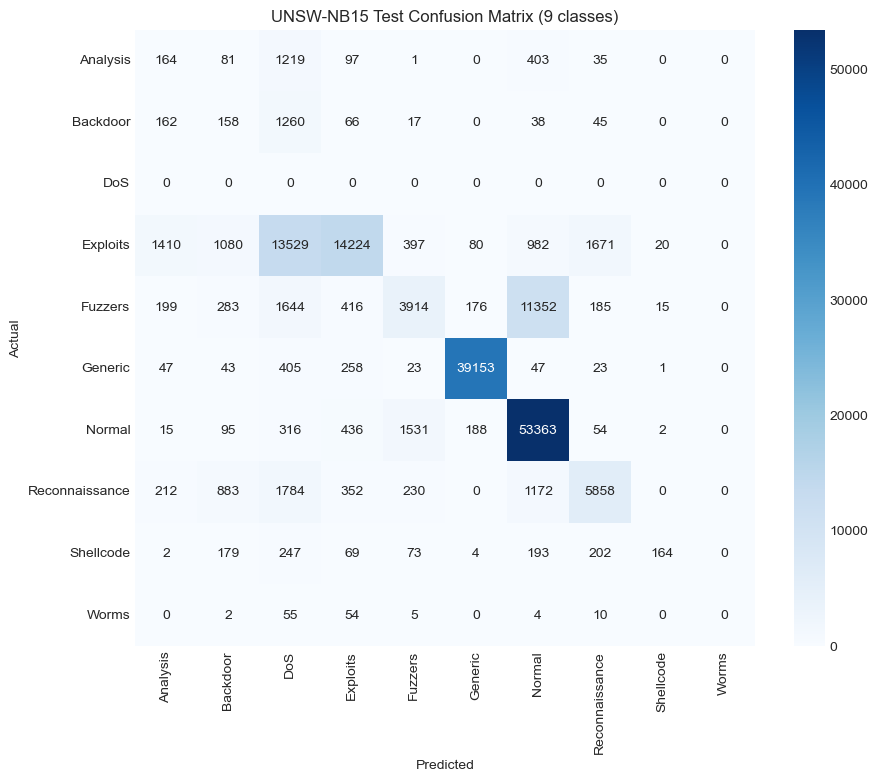

In [67]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

y_prob = model.predict(X_test_3d, verbose=0)
y_pred = y_prob.argmax(axis=1)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=list(le_y.classes_), zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=range(len(le_y.classes_)))
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(le_y.classes_), yticklabels=list(le_y.classes_))
plt.title('UNSW-NB15 Test Confusion Matrix (9 classes)')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()


In [68]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Predict on the prepared test tensor
y_prob = model.predict(X_test_3d, verbose=0)
y_pred = y_prob.argmax(axis=1)

acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {bacc:.4f}")


Test Accuracy: 0.7174
Balanced Accuracy: 0.3832


C:\Users\acer\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [69]:
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn

import pandas as pd, numpy as np, tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

RANDOM_STATE = 42
tf.keras.utils.set_random_seed(RANDOM_STATE)


In [70]:
TRAIN_FILE = "UNSW_NB15_training-set.csv"
TEST_FILE  = "UNSW_NB15_testing-set.csv"

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)

# Normalize labels (title case to avoid drift)
for df in (train_df, test_df):
    df['attack_cat'] = df['attack_cat'].astype(str).str.strip().str.title()

# 9-class label encoder on train only
le_y = LabelEncoder()
y_train = le_y.fit_transform(train_df['attack_cat'])
y_test  = le_y.transform(test_df['attack_cat'])  # UNSW splits align

classes9 = list(le_y.classes_)
num_classes = len(classes9)
print("Classes:", classes9)


Classes: ['Analysis', 'Backdoor', 'Dos', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [71]:
# Select features: drop identifiers and labels
DROP = ['id','attack_cat','label']  # 'label' is binary; we’re using 9-class attack_cat
X_train_df = train_df.drop(columns=[c for c in DROP if c in train_df.columns], errors='ignore')
X_test_df  = test_df.drop(columns=[c for c in DROP if c in test_df.columns], errors='ignore')

# Encode common categoricals
cat_cols = [c for c in ['proto','service','state'] if c in X_train_df.columns]
encoders_feat = {}
for c in cat_cols:
    le = LabelEncoder()
    X_train_df[c] = le.fit_transform(X_train_df[c].astype(str))
    # unknown-safe for test
    vals = X_test_df[c].astype(str)
    seen = set(le.classes_)
    UNK = "__UNK__"
    if UNK not in le.classes_:
        le.classes_ = np.array(list(le.classes_) + [UNK])
    X_test_df[c] = [v if v in seen else UNK for v in vals]
    X_test_df[c] = le.transform(X_test_df[c])
    encoders_feat[c] = le

# Scale numerics
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_df)
X_test_sc  = scaler.transform(X_test_df)

# Build square “images”: HxW≈sqrt(n_features)
F = X_train_sc.shape[1]
H = int(np.floor(np.sqrt(F)))
W = int(np.ceil(F / H))
PAD = H*W - F
if PAD > 0:
    X_train_sc = np.pad(X_train_sc, ((0,0),(0,PAD)), mode='constant')
    X_test_sc  = np.pad(X_test_sc,  ((0,0),(0,PAD)), mode='constant')

# Reshape to (N, H, W, 1)
X_train_2d = X_train_sc.reshape((-1, H, W, 1)).astype('float32')
X_test_2d  = X_test_sc.reshape((-1, H, W, 1)).astype('float32')
print("Conv2D input shape:", X_train_2d.shape)


Conv2D input shape: (82332, 6, 7, 1)


In [72]:
from tensorflow.keras import layers, models

def build_cnn_feature_extractor(h, w, dropout=0.35):
    inputs = layers.Input(shape=(h, w, 1))
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same', name='Conv2D_1')(inputs)
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(pool_size=(2,2), name='MaxPool_1')(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Conv2D(128, (3,3), activation='relu', padding='same', name='Conv2D_2')(x)
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(pool_size=(2,2), name='MaxPool_2')(x)
    x = layers.Dropout(dropout)(x)

    # Keep spatial map for LSTM sequence extraction
    model = models.Model(inputs, x, name='CNN_FeatureExtractor')
    return model

cnn = build_cnn_feature_extractor(H, W, dropout=0.35)
cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy',  # dummy for warmup; not used for final
            metrics=['accuracy'])

cnn.summary()


Model: "CNN_FeatureExtractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 6, 7, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_1 (Conv2D)               │ (None, 6, 7, 32)       │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 6, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 3, 3, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 1, 1, 128)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,256 (938.50 KB)

 Trainable params: 240,256 (938.50 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
# Optional: attach a temporary classification head for warm-up
temp_in = cnn.input
temp_x = cnn.output
temp_x = layers.GlobalAveragePooling2D()(temp_x)
temp_out = layers.Dense(num_classes, activation='softmax')(temp_x)
cnn_head = models.Model(temp_in, temp_out, name='CNN_Warmup')

# Class weights to mitigate imbalance
cls = np.unique(y_train)
cw = compute_class_weight('balanced', classes=cls, y=y_train)
class_weights = {int(c): float(w) for c,w in zip(cls, cw)}

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1),
]

cnn_head.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

hist_cnn = cnn_head.fit(
    X_train_2d, y_train,
    validation_split=0.2,
    epochs=80, batch_size=128,
    class_weight=class_weights,
    callbacks=callbacks, verbose=1
)


Epoch 1/80
515/515 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7593 - loss: 1.3687 - val_accuracy: 0.2357 - val_loss: 2.4493 - learning_rate: 0.0010
Epoch 2/80
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7805 - loss: 1.0896 - val_accuracy: 0.2357 - val_loss: 2.4297 - learning_rate: 0.0010
Epoch 3/80
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7829 - loss: 1.0641 - val_accuracy: 0.2409 - val_loss: 2.6080 - learning_rate: 0.0010
Epoch 4/80
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7842 - loss: 1.0309 - val_accuracy: 0.2544 - val_loss: 2.4023 - learning_rate: 0.0010
Epoch 5/80
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7843 - loss: 1.0382 - val_accuracy: 0.2459 - val_loss: 2.5574 - learning_rate: 0.0010
Epoch 6/80
509/515 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7828 - loss: 1.0208
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
515/515 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7846 - loss: 1.0252 - v

C:\Users\acer\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 24 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


ValueError: A total of 5 objects could not be loaded. Example error message for object <Conv1D name=conv1d, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(3, 1, 64), Received: value.shape=(5, 1, 128). Target variable: <Variable path=conv1d/kernel, shape=(3, 1, 64), dtype=float32, value=[[[ 0.13377996  0.00275005  0.03806287  0.22702576 -0.75366735
    0.17242138  0.0649009  -0.47246802  0.03305835  0.08400226
   -0.4561114   0.02123607  0.15861663 -0.43200526 -0.4582336
    0.19568214 -0.2616992  -0.5262766   0.03123099 -0.54201764
    0.02384227  0.2101155   0.24820268  0.07115505  0.01581425
   -0.681326    0.03911798 -0.01345967  0.01169442  0.03944876
   -0.5215693   0.17535254 -0.48915946  0.18859164  0.02624394
    0.09006348  0.19020805 -0.5255166   0.04769241  0.13877924
   -0.06361754 -0.00317604  0.05131966  0.07729934  0.22259684
   -0.7239774   0.0980375  -0.02968739 -0.5686833   0.127

In [77]:
# Continue training for remaining epochs
history2 = model.fit(
    X_train_3d, y_train,
    validation_split=0.2,
    epochs=80,              # keep total epochs = 80
    initial_epoch=17,       # start from where you stopped
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 236800
'y' sizes: 82332
'sample_weight' sizes: 82332
